<a href="https://colab.research.google.com/github/Text-Machine/mask-predict/blob/main/chr-paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> </a>

# CHR Paper notebook

This notebook aims to reproduce all figures and tables that inform the analysis of the CHR paper.

In [ ]:
!git clone https://github.com/Text-Machine/mask-predict.git

In [ ]:
%cd mask-predict

In [ ]:
!pip install -q -e .

In [4]:
import pandas as pd
import json
from tqdm import tqdm
from explain import *
from pathlib import Path
from collections import Counter
import seaborn as sns

In [5]:
%cd /content

[Errno 2] No such file or directory: '/content'
/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict


In [ ]:
!gdown 125wfZ1P9MfFZ19XS2SCfallsnoNhLCUf

In [ ]:
!unzip -o "chr-data.zip"

note about explanation of data and choices to made here

In [6]:
collection,genre_suffix = 'blb',''
if collection == 'blb':
  genre_suffix = '_with_genre'

TargetMaskedToken = 'machine' # the token to be masked in the target sentence
try:
  import google.colab
  originalFolder = '.' # change to '.' when working in colab
  dataPath = '.' # change to '.' when working in colab 
  processedFolder = '.' # change '.' when working in colab
except:
  originalFolder = 'masking_data' # change to '.' when working in colab
  dataPath = 'input_data' # change to '.' when working in colab 
  processedFolder = 'gradient_data' # change '.' when working in colab

predCol = "pred_bert_1760_1900"
resultType = 'pred_kw_filtered' # pred | pred_kw_filter

print(f"This analysis focuses on '{TargetMaskedToken}' in the {collection} collection.")

This analysis focuses on 'machine' in the blb collection.


We are loading the data frame with deduplicated sentences.

In [7]:
df_sent_all = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}_clusters{genre_suffix}_deduplicated.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent_all.shape[0]} unique sentences for the target token {TargetMaskedToken} in the {collection} collection.')


We have 77907 unique sentences for the target token machine in the blb collection.


In [8]:
# load the original sentences with the predicted tokens
df_sent = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}{genre_suffix}_{resultType}.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent.shape[0]} sentences that produced human predictions for the target token {TargetMaskedToken} in the {collection} collection.')
df_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_{resultType}_processed.csv', index_col=0 )
print(f'We have {df_ig.shape[0]} explanations for the target token {TargetMaskedToken} in the {collection} collection.')
print('Checking alignment sentence data and gradients:',df_sent.shape[0]==df_ig['id'].max()+1)


We have 18792 sentences that produced human predictions for the target token machine in the blb collection.
We have 2256709 explanations for the target token machine in the blb collection.
Checking alignment sentence data and gradients: True


In [9]:
df_sent['id'] = range(df_sent.shape[0])

# Add Perplexity Information



In [10]:

df_sent_all['token_pseudo_ppl_processed'] = df_sent_all['token_pseudo_ppl'].apply(lambda x: merge_subtokens(eval(x)))
df_sent['token_pseudo_ppl'] = df_sent['token_pseudo_ppl'].apply(lambda x: eval(x))
df_sent['token_pseudo_ppl_processed'] = df_sent['token_pseudo_ppl'].apply(merge_subtokens)
df_sent_perpl = df_sent[['id','genre','token_pseudo_ppl_processed']].explode('token_pseudo_ppl_processed', ignore_index=True)
df_ig[df_ig.Target.isin(['machine', 'machines'])].shape,df_sent_perpl.shape

((787259, 11), (799153, 3))

In [11]:
df_sent_perpl[['Token','perplexity']] = pd.DataFrame(df_sent_perpl.token_pseudo_ppl_processed.tolist(), index=df_sent_perpl.index)

In [12]:
from collections import defaultdict, Counter
def index_duplicates(tokens):
    indexed_sent = []
    wf = Counter(tokens)
    counts = defaultdict(int)
    for t in tokens:
        if wf[t] >= 2:
            counts[t]+=1
            indexed_sent.append(f'{t}_{counts[t]}')
        else:
            indexed_sent.append(t)
    return indexed_sent


In [13]:
#df_ig['Token_id'] = df_ig.groupby('id').apply(lambda x: x.groupby(['Target'])['Token'].transform(index_duplicates))
df_ig['Token_id'] = df_ig.apply(lambda x: x['Token'] if x['Token'] != '[MASK]' else x['Target'], axis=1)
df_ig['Token_id'] = df_ig.groupby(['id','Target'])['Token_id'].transform(index_duplicates)
df_sent_perpl['Token_id'] = df_sent_perpl.groupby(['id'])['Token'].transform(index_duplicates)
df_ig_perpl = df_ig.merge(df_sent_perpl, on=['id','Token_id'], how='left')
df_ig_perpl.shape, df_ig.shape



((2256709, 16), (2256709, 12))

Here we load the words that we selected as human prediction, i.e. these are words predicted by BLERT possible referring to human fillers for the masked machine token.

In [14]:
# with open(f'{dataPath}/100_freq_pred_BL_edit.txt') as f:
#     human_words = f.read().splitlines()
df_words = pd.read_csv(f"{dataPath}/word_human_clusters_v5_edit.csv")
human_words = list(df_words[df_words['human_likelihood'] > .1]['word'])

print(human_words[:10], len(human_words))

['man', 'men', 'woman', 'child', 'people', 'person', 'boy', 'girl', 'hands', 'children'] 225


We create a new column where filter the prediction, only retaining the human words.

In [15]:
for colName in ['pred_bert_contemporary', 'pred_bert_1760_1900']:
    df_sent[f'{colName}_human'] = df_sent[colName].apply(
        lambda x: {w:s for w, s in dict(eval(x)).items() if w in human_words})


We look at results by decade, therefore adding decade column to the data frames

In [16]:

if collection == 'hmd':
    df_sent_all['date'] = df_sent_all['year']
    df_sent['date'] = df_sent['year']
df_sent_all['decade'] = df_sent_all['date'].apply(lambda x: int(x/10)*10)
df_sent['decade'] = df_sent['date'].apply(lambda x: int(x/10)*10)

## Analysis: Perplexity

In [17]:
(sum(df_ig_perpl['perplexity'] >= 10_000) / len(df_ig_perpl['perplexity']))*100

3.8242857187169457

In [18]:
import numpy as np
perpl_upper_thr = 10_000
df_sent_all['perplexity_threshold'] = df_sent_all['token_pseudo_ppl_processed'].apply(lambda x: np.mean([min(v,perpl_upper_thr) for k, v in x]))
df_ig_perpl['perplexity_threshold'] = df_ig_perpl['perplexity'].apply(lambda x: min(x, perpl_upper_thr))
print('removing extreme values (in %):',(sum(df_ig_perpl['perplexity_threshold'] >= perpl_upper_thr) / len(df_ig_perpl['perplexity_threshold']))*100)
df_sent_all['log_perplexity'] = np.log(df_sent_all['perplexity_threshold'])

removing extreme values (in %): 3.8242857187169457


<Axes: xlabel='perplexity_threshold', ylabel='genre'>

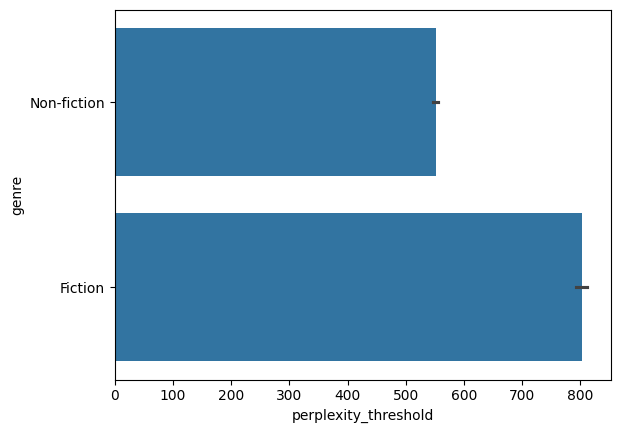

In [19]:
sns.barplot(x='perplexity_threshold', y='genre', data=df_sent_all[df_sent_all['decade'].between(1800,1899)])

<Axes: xlabel='perplexity_threshold', ylabel='genre'>

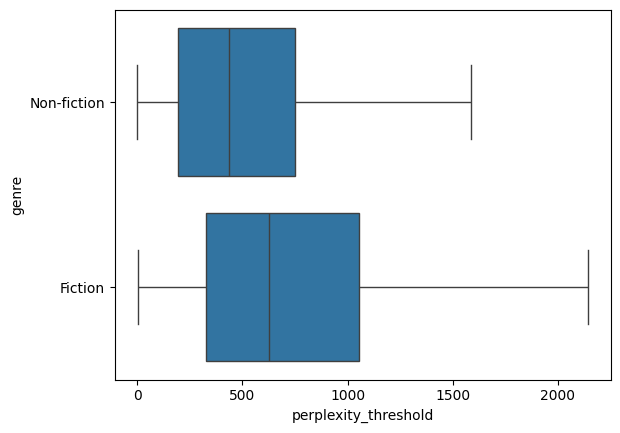

In [20]:
sns.boxplot(x='perplexity_threshold', y='genre', data=df_sent_all[df_sent_all['decade'].between(1800,1899)], showfliers=False)

In [21]:
df_sent_all['human_prediction'] = df_sent_all['pred_bert_1760_1900'].apply(lambda x: bool({w:s for w, s in dict(eval(x)).items() if w in human_words}))
df_sent_all['human_prediction_max'] = df_sent_all['pred_bert_1760_1900'].apply(lambda x: max([s for w, s in dict(eval(x)).items() if w in human_words]+[0]))

<Axes: xlabel='perplexity_threshold', ylabel='genre'>

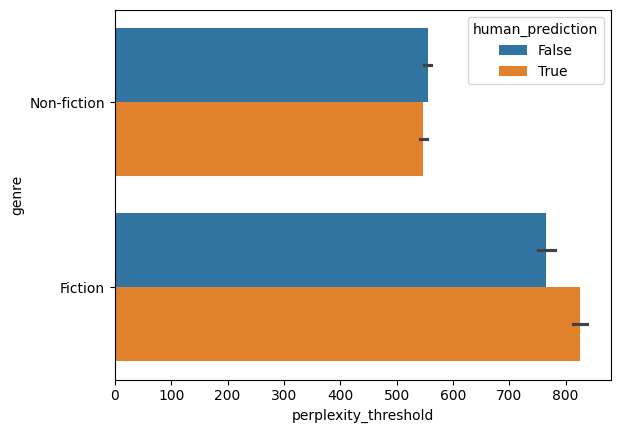

In [22]:
sns.barplot(x='perplexity_threshold', y='genre', hue='human_prediction', data=df_sent_all[df_sent_all['decade'].between(1800,1899)])

#.plot(kind='bar', title='Average Perplexity by Genre and Human Prediction', ylabel='Average Perplexity', xlabel='Genre')

<Axes: title={'center': 'Average Perplexity by Genre and Human Prediction'}, xlabel='Genre', ylabel='Average Perplexity'>

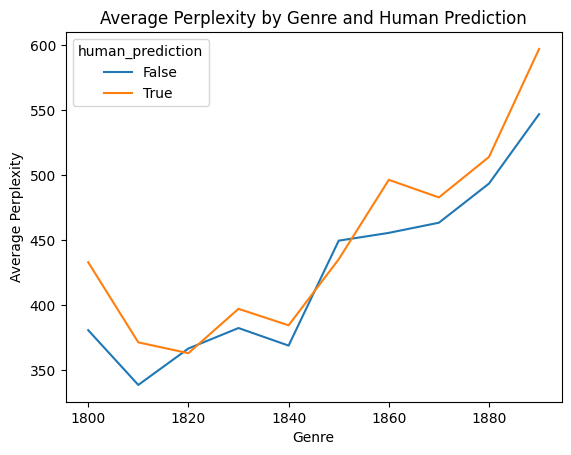

In [23]:
df_sent_all[df_sent_all['decade'].between(1800,1899)].groupby(['decade','human_prediction'])['perplexity_threshold'].median().unstack().plot( title='Average Perplexity by Genre and Human Prediction', ylabel='Average Perplexity', xlabel='Genre')

<Axes: title={'center': 'Average Perplexity by Genre and Human Prediction'}, xlabel='Genre', ylabel='Average Perplexity'>

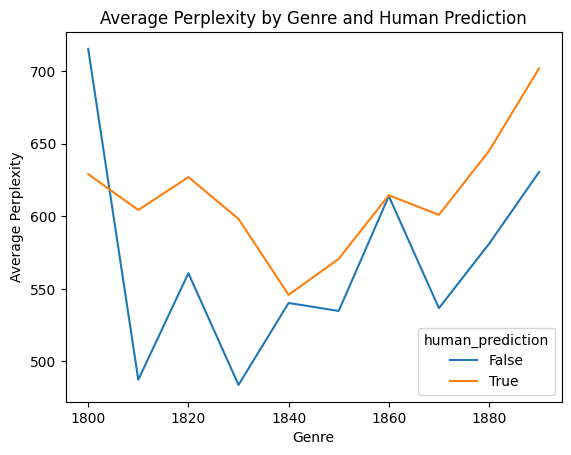

In [24]:
df_sent_all[(df_sent_all['decade'].between(1800,1899)) & (df_sent_all['genre']=='Fiction')].groupby(['decade','human_prediction'])['perplexity_threshold'].median().unstack().plot( title='Average Perplexity by Genre and Human Prediction', ylabel='Average Perplexity', xlabel='Genre')

<Axes: xlabel='decade', ylabel='perplexity_threshold'>

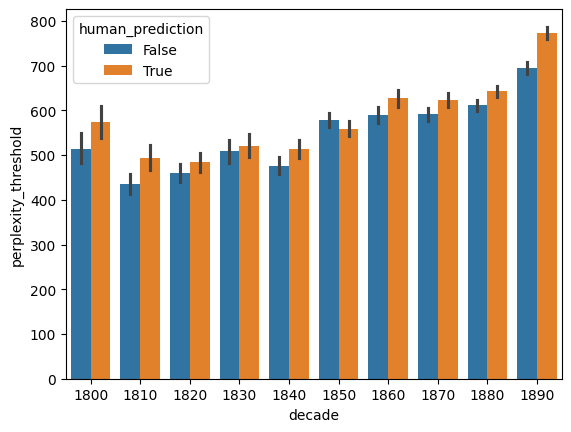

In [25]:
sns.barplot(y='perplexity_threshold',x='decade', data=df_sent_all[df_sent_all['decade'].between(1800,1899)], hue='human_prediction')

<Axes: xlabel='decade', ylabel='perplexity_threshold'>

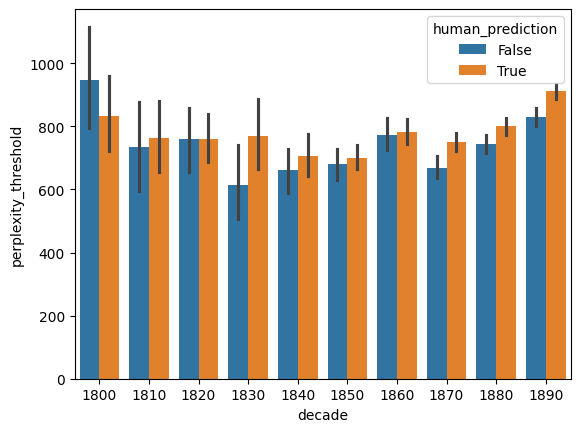

In [26]:
sns.barplot(y='perplexity_threshold',x='decade', data=df_sent_all[(df_sent_all['decade'].between(1800,1899)) & (df_sent_all['genre']=='Fiction') ], hue='human_prediction')

<Axes: title={'center': 'Average Perplexity by Genre and Human Prediction'}, xlabel='Genre', ylabel='Average Perplexity'>

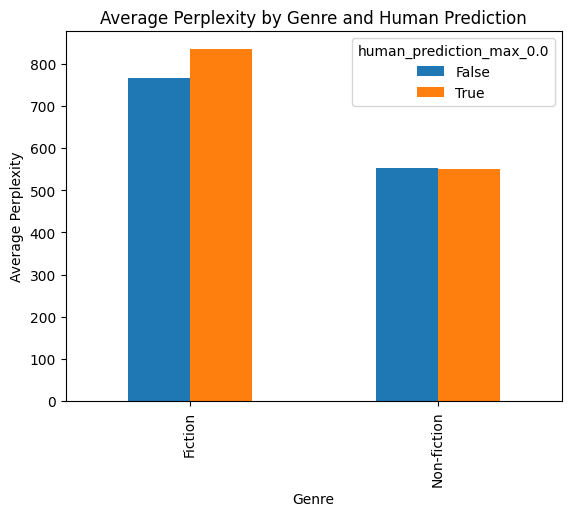

In [27]:
threshold = .0
df_sent_all[f'human_prediction_max_{threshold}'] = df_sent_all['human_prediction_max'] > threshold
df_sent_all.groupby(['genre',f'human_prediction_max_{threshold}'])['perplexity_threshold'].mean().unstack().plot(kind='bar', title='Average Perplexity by Genre and Human Prediction', ylabel='Average Perplexity', xlabel='Genre')

<Axes: title={'center': 'Average Perplexity by Genre and Human Prediction'}, xlabel='Genre', ylabel='Average Perplexity'>

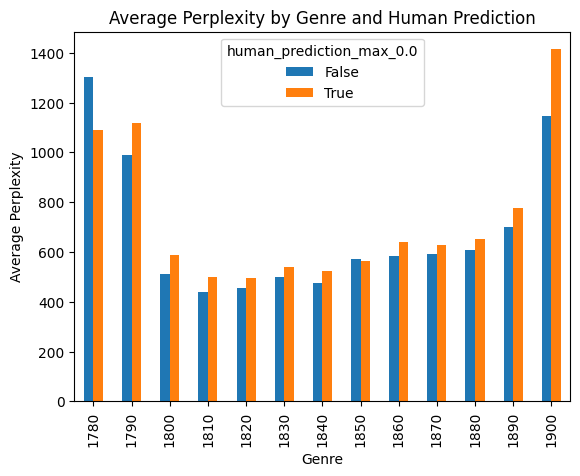

In [28]:
df_sent_all.groupby(['decade',f'human_prediction_max_{threshold}'])['perplexity_threshold'].mean().unstack().plot(kind='bar', title='Average Perplexity by Genre and Human Prediction', ylabel='Average Perplexity', xlabel='Genre')

### Analysis: explainability

Which words drive the predictions, and especially, how to interpet this increasing "confusion" or children with machines? What does it tell us about changes in the discourse about machines.

What we compute is not just how words contribute to the prediction, this tells us often more about what type of sentences are included in our data. We look at which words explain the difference between machine and human words, i.e. which words drive the prediction towards 'human' and away from 'machine'.

More technically, for each word in the sentence we compute pairwise differences between ''machine'' and ''human'' predictions (for the masked token) for each token in the sentence.

In [29]:
# Create row order within each id and Target
df_ig_perpl["row_idx"] = df_ig.groupby(["id", "Target"]).cumcount()

# Extract machine/machines scores
machine_scores = (
    df_ig_perpl[df_ig_perpl["Target"].isin(["machine", "machines"])]
    [["id", "row_idx", "Score_normalized"]]
    .rename(columns={"Score_normalized": "machine_score"})
)

# Match each row with the corresponding machine row
df_ig_perpl = df_ig_perpl.merge(
    machine_scores,
    on=["id", "row_idx"],
    how="left"
)

# Subtract
df_ig_perpl["diff"] = df_ig_perpl["Score_normalized"] - df_ig_perpl["machine_score"]

# Optional: remove helper column
df_ig_perpl.drop(columns=["row_idx", "machine_score"], inplace=True)

In [30]:
df_ig_perpl[(df_ig_perpl['id'] == 11)].Target.unique()

<ArrowStringArray>
['girls', 'machine']
Length: 2, dtype: str

In [31]:
df_ig_perpl[(df_ig_perpl['id'] == 11) & (df_ig_perpl['Target'].isin(['machine', 'machines']))][['Target', 'Score_normalized', 'diff']].head(3)

,Target,Score_normalized,diff
1547,machine,0.000787,0.0
1548,machine,0.016184,0.0
1549,machine,0.009033,0.0


## Analysis: explainabiliy and perplexity

Q: Is the perplexity significantly higher for these context words?

## Analysis: Explanation scores for a specific theme


The code below, repeats the contextual analyis, but focussing on specific theme, defined by the `comparisonTokens` variable. Here we highlight which context words explain the drifting aways of explanations from the machine, with regard to a specific theme.

The `threshold`  regulates, the confidence.

`comarisonTokens` defines a set of words which we compare against machine predictions.

The `df_result` dataframe shows the words that exhibit the highest difference between machine and human words. Below we provide tools for analysing these words, and the sentences, in which they appear, in more depth.

In [32]:
# with open(f'{dataPath}/100_freq_pred_BL_edit.txt') as f:
#     human_words = f.read().splitlines()
df_words = pd.read_csv(f"{dataPath}/word_human_clusters_v5_edit.csv")
df_words.fillna('', inplace=True)
human_words = list(df_words[df_words['human_likelihood'] > .1]['word'])

print(human_words[:10], len(human_words))

cols = list(df_words.columns[2:])
for c in cols:
    exec(f"{c}2word = {{}}")

    for i, row in df_words.iterrows():
        if row['human_likelihood'] <= threshold:
            continue

        for hc in row[c].split(';'):
            exec(f"if hc not in {c}2word and hc != '': {c}2word[hc] = []")
            if hc != '':
                exec(f"{c}2word[hc].append(row['word'])")
    print(f"Created a dictionary for {c} with {len(eval(c+'2word'))} keys.")



['man', 'men', 'woman', 'child', 'people', 'person', 'boy', 'girl', 'hands', 'children'] 225
Created a dictionary for chr_categories with 8 keys.
Created a dictionary for semantic_clusters with 11 keys.
Created a dictionary for human_subcategory with 23 keys.
Created a dictionary for pos_category with 3 keys.
Created a dictionary for animacy_tier with 5 keys.
Created a dictionary for domain_topic with 26 keys.
Created a dictionary for concreteness with 2 keys.
Created a dictionary for connotation_register with 4 keys.


In [33]:
for colName in ['pred_bert_1760_1900']:
    for k, word_list in chr_categories2word.items():
        df_sent_all[f'{colName}_{k}'] = df_sent_all[colName].apply(
            lambda x: {w:s for w, s in dict(eval(x)).items() if w in word_list})


In [34]:
df_ig_perpl.rename(columns={'Token_x':'Token'}, inplace=True)

In [35]:
#comparisonTokens = ['child','children', 'boy','boys','girl','girls']
comparisonTokens = chr_categories2word['age_status']
lower_conf_thresh = .0
print(comparisonTokens)
df_comparisonConcept = df_ig_perpl[
    (df_ig_perpl['Target'].isin(comparisonTokens)) & \
    (df_ig_perpl['Target_score'].between(lower_conf_thresh, 1.0)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


['child', 'boy', 'girl', 'children', 'boys', 'girls', 'baby', 'lad', 'infant', 'lads', 'youth', 'youths']


In [36]:
age_status_id = set().union(*df_comparisonConcept['identifiers'].values)
len(age_status_id)

1714

In [37]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 5
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False)
df_result.head(20)

,Token,count,identifiers,avg_diff,avg_score
4875,mowing,15,"{10084, 8741, 8710, 18053, 585, 7337, 7307, 43...",0.001124,0.040987
3907,infernal,7,"{16614, 11370, 13360, 4370, 13300, 11252, 11198}",0.019658,0.040695
3445,guide,7,"{11813, 6055, 14155, 11389, 11390}",0.023361,0.040372
6634,sewing,215,"{8192, 1, 2, 3, 14852, 518, 9734, 9735, 12809,...",-0.032812,0.039310
777,babies,5,"{7186, 16644, 1405}",0.004407,0.037941
7435,tended,5,"{11200, 12808, 8074}",0.025294,0.034679
6777,singing,10,"{8074, 3213, 726, 13143, 2044, 7902, 12383}",0.023236,0.034393
4151,kicked,5,"{17046, 17047}",NaN,0.032614
7530,thrashing,5,"{3400, 4105, 11144, 4171, 15829}",-0.003524,0.031566
862,beast,7,"{6952, 16945, 8307, 2934, 2871}",0.003456,0.030975


# Analysis: Pre-interpretation of Claude

In [34]:
import anthropic

with open('api_key.json') as f:
    anthropic_api_key = json.load(f)['anthropic_api_key']

anthropic_client = anthropic.Anthropic(api_key=anthropic_api_key)

def prompt_claude(client, messages, model="claude-opus-5", max_tokens=1024):
        return client.messages.create(model=model, max_tokens=max_tokens, messages=messages)
    

In [50]:
import time
import random

def prompt_claude_with_retry(
    client,
    messages,
    model="claude-opus-5",
    max_tokens=1024,
    max_retries=5,
    initial_delay=1.0,
    backoff_factor=2.0,
    retry_exceptions=(
        anthropic.APIConnectionError,
        anthropic.APITimeoutError,
        anthropic.RateLimitError,
        anthropic.InternalServerError,
        anthropic.OverloadedError,  # 529 - Anthropic servers temporarily overloaded
    ),
):
    """Call prompt_claude, retrying with exponential backoff on transient errors.

    Retries on connection/timeout/rate-limit/server errors; other exceptions
    (e.g. AuthenticationError, BadRequestError) are raised immediately since
    retrying them won't help.
    """
    delay = initial_delay
    last_exc = None
    for attempt in range(1, max_retries + 1):
        try:
            return prompt_claude(client, messages, model=model, max_tokens=max_tokens)
        except retry_exceptions as e:
            last_exc = e
            if attempt == max_retries:
                break
            sleep_for = delay + random.uniform(0, delay * 0.1)
            print(f"[retry {attempt}/{max_retries}] {type(e).__name__}: {e} — retrying in {sleep_for:.1f}s")
            time.sleep(sleep_for)
            delay *= backoff_factor
    raise last_exc


In [119]:
USER_PROMPT = """A hybrid understanding of machines treats mechanical and living/emotional registers as interpenetrating rather than opposed — machines are described with vitality, feeling, or agency, and/or humans are described in mechanical terms — rather than machines being cast simply as soulless, inert objects in contrast to a living, feeling human/organic world.
Does the sentence between ### reflect a hybrid understanding of machines, where mechanical and living/emotional registers are interpenetrating rather than opposed? 
Also, does the sentence contain an anthropomorphic or technomorphic description? Use these definitions:
- Anthropomorphism: the projection of human features, qualities, or agency onto machines — describing mechanical objects as if they had human characteristics (feeling, will, vitality).
- Technomorphism: the inverse move — describing humans (or human bodies, minds, and behavior) in machine-like terms, projecting mechanical qualities (function, mere repetition, lack of agency) onto people.

SENTENCE:
###
{SENTENCE}
###

Provide a brief summary for your answer in maximum 50 words.
Provide a binary 'Yes' or 'No' answer to the question.
Provide a brief explanation why the following words are relevant to your answer or not (max 50 words). If not words are given return 'empty': '{WORDS}'.
Classify your answer as either 'anthropomorphism', 'technomorphism' or 'neutral'.

Return your answer in JSON format with the following keys: 'summary','hybrid_binary','explanation','classification'.
"""

In [120]:
USER_PROMPT_CLASSIFICATION = """Does the sentence contain an anthropomorphic or technomorphic description? Use these definitions:
- Anthropomorphism: the projection of human features, qualities, or agency onto machines — describing mechanical objects as if they had human characteristics (feeling, will, vitality).
- Technomorphism: the inverse move — describing humans (or human bodies, minds, and behavior) in machine-like terms, projecting mechanical qualities (function, mere repetition, lack of agency) onto people.

SENTENCE:
###
{SENTENCE}
###

Classify your answer as either 'anthropomorphism', 'technomorphism' or 'neutral'.
Provide a brief explanation (max 50 words).

Return your answer in JSON format with the following keys: 'classification' and 'explanation'.
"""

In [53]:
lin = np.linspace(0, 1, 5)
examples = []
for lower_bound, upper_bound in zip(lin[:-1], lin[1:]):
    sample = df_sent_all[(df_sent_all['human_prediction_max'].between(lower_bound, upper_bound)) & (df_sent_all['decade'].between(1800, 1899))].sample(n=50, random_state=42)
    sample['id'] = sample.index
    examples.append(sample[['currentSentence', 'human_prediction_max', 'id']])

examples_df = pd.concat(examples, ignore_index=True)
examples_df.to_csv(f'claude_output/examples_{collection}_{TargetMaskedToken}_human_prediction_max_filtered.csv', index=False)

In [55]:
from tqdm import tqdm
tqdm.pandas(desc="Prompting Claude for classification")
examples_df['response']  = examples_df.progress_apply(
    lambda x: prompt_claude_with_retry(anthropic_client, 
                                       messages=[{"role": "user", "content": USER_PROMPT_CLASSIFICATION.format(SENTENCE=x['currentSentence'])}], model="claude-sonnet-5", max_tokens=1024),
                                         axis=1)


Prompting Claude for classification: 100%|██████████| 200/200 [09:26<00:00,  2.83s/it]


In [79]:
examples_df[[ 'classification', 'explanation' ]] = pd.DataFrame(list(examples_df.apply(
    lambda x: json.loads(x['response'].content[-1].text.lstrip('```json').rstrip('```').strip() ),
    axis=1
)))

In [81]:
examples_df[
        ['currentSentence', 'human_prediction_max', 'id', 'classification', 'explanation']
            ].to_csv(f'claude_output/examples_{collection}_{TargetMaskedToken}_human_prediction_max_filtered_classified.csv', index=False)

In [86]:
np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [87]:
examples_df['category'] =pd.cut(examples_df['human_prediction_max'], right=False, bins=np.linspace(0, 1, 5), labels=False)

<Axes: title={'center': 'Distribution of human prediction scores'}, xlabel='Human prediction score', ylabel='Number of sentences'>

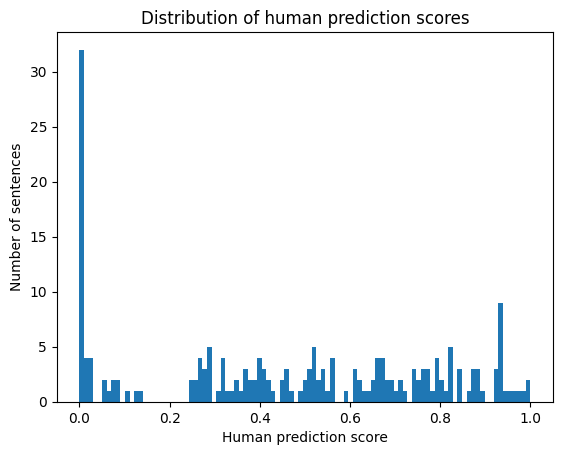

In [102]:
examples_df.human_prediction_max.plot(kind='hist', bins=np.linspace(0, 1, 100), title='Distribution of human prediction scores', ylabel='Number of sentences', xlabel='Human prediction score')

<Axes: xlabel='category,classification'>

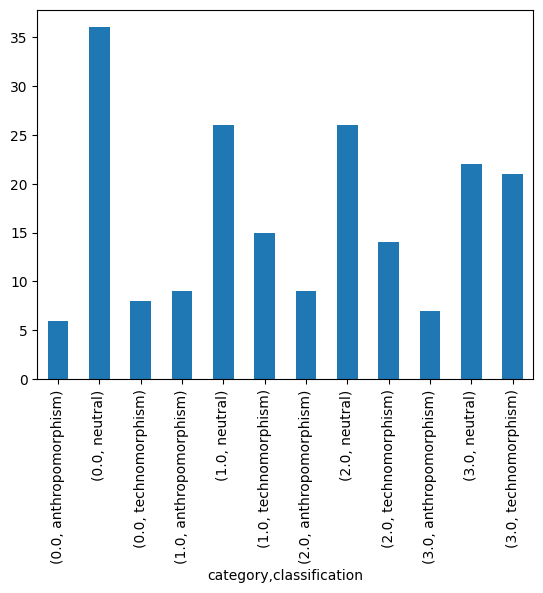

In [98]:
examples_df.groupby(['category','classification'])['id'].count().plot(kind='bar')

#.reset_index(name='count').plot(x='category', y='count', kind='bar', title='Number of sentences per human prediction category', ylabel='Number of sentences', xlabel='Human prediction category')

In [121]:
idx_start,idx_end = 0,5
lower_conf_thresh = .01
prompts = []
# for i,row in df_result.iloc[idx_start:idx_end].iterrows():
#     #print(row['identifiers'])
for idx in age_status_id:#row['identifiers']:
        target = df_ig_perpl[(df_ig_perpl['id'] == idx) & (df_ig_perpl['Target_position'] >= 0)].sort_values(by='Target_position', ascending=True)['Target'].unique()[0]
        sentence = df_sent[df_sent['id'] == idx]['currentSentence'].values[0]
        #prev_sentence = df_sent[df_sent['id'] == idx]['prevSentence'].values[0]
        words = df_ig_perpl[(df_ig_perpl['id'] == idx) & (df_ig_perpl['Target'] == target) & (df_ig_perpl['Score_normalized'] > lower_conf_thresh)].sort_values(by='Score_normalized', ascending=False)['Token'].unique().tolist()
        if words:
            words = ', '.join(words)
        else:
            words = ''
        messages = [
            {
                "role": "user", 
                "content": USER_PROMPT.format(SENTENCE=sentence, WORDS=words)
            }
            ]
        prompts.append((idx,messages))


In [122]:
print(prompts[0][1][0]['content'])

A hybrid understanding of machines treats mechanical and living/emotional registers as interpenetrating rather than opposed — machines are described with vitality, feeling, or agency, and/or humans are described in mechanical terms — rather than machines being cast simply as soulless, inert objects in contrast to a living, feeling human/organic world.
Does the sentence between ### reflect a hybrid understanding of machines, where mechanical and living/emotional registers are interpenetrating rather than opposed? 
Also, does the sentence contain an anthropomorphic or technomorphic description? Use these definitions:
- Anthropomorphism: the projection of human features, qualities, or agency onto machines — describing mechanical objects as if they had human characteristics (feeling, will, vitality).
- Technomorphism: the inverse move — describing humans (or human bodies, minds, and behavior) in machine-like terms, projecting mechanical qualities (function, mere repetition, lack of agency)

In [123]:
len(prompts)

1714

In [124]:
prompts[0]

(8192,
 [{'role': 'user',
   'content': "A hybrid understanding of machines treats mechanical and living/emotional registers as interpenetrating rather than opposed — machines are described with vitality, feeling, or agency, and/or humans are described in mechanical terms — rather than machines being cast simply as soulless, inert objects in contrast to a living, feeling human/organic world.\nDoes the sentence between ### reflect a hybrid understanding of machines, where mechanical and living/emotional registers are interpenetrating rather than opposed? \nAlso, does the sentence contain an anthropomorphic or technomorphic description? Use these definitions:\n- Anthropomorphism: the projection of human features, qualities, or agency onto machines — describing mechanical objects as if they had human characteristics (feeling, will, vitality).\n- Technomorphism: the inverse move — describing humans (or human bodies, minds, and behavior) in machine-like terms, projecting mechanical qualitie

In [125]:
model = "claude-sonnet-5"
responses = {idx: prompt_claude_with_retry(anthropic_client, messages=messages, model=model) for idx, messages in tqdm(prompts)}

100%|██████████| 1714/1714 [2:18:18<00:00,  4.84s/it]  


In [142]:
theme = 'age_status'
results = []
errors = 0
for idx, response in responses.items():

    try:
        content = json.loads(response.content[-1].text.lstrip('```json').rstrip('`').replace('"",',''))
    except (json.JSONDecodeError, IndexError):
        print(f"Error decoding JSON for ID {idx}")
        print(response.content)
        errors+=1
        continue
    content['sentId'] = idx
    results.append(content)
pd.DataFrame(results).to_csv(f'claude_output/results_{collection}_{TargetMaskedToken}_{theme}_claude_sonnet5.csv', index=False)
print(f"Total errors: {errors}")

Error decoding JSON for ID 8758
[ThinkingBlock(signature='EqcKCokBCBAYAipAhMX3/XiR5iG2Aq/oOSjBbuLLpecM9iIrygZcWeg6p/+6ZggHwlDb8NtU2Us/Fj30igFW1oinu9SAh3hCbfqI4DIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiQ2YTZkZTAwNS0wOWRiLTRiMzktOTM3ZC01YmU3NzYwNWI2MmQSDGSJSFSMH6Z8WBFCkRoMSE2BhMHoF891IAObIjBtSxxEDPxqO1yaXm1gsGQ8dLgnS5uwuVy4efcPQ/WiTLEthuuFJ3SbV1/XSge3FB4qygjP8DjSlnsTzphDEh5SYCgcyzfj23c/4g5ZeJehPBSB5VidNj57/s5eMonda9aElKxwH60cyWx8KmDCMbhjQx7W2vOpI4FR83KJQOxjyo7RUkDm1MEgjGeF4Byq44wCRmEjYKNLi+1vUQYuRfWYq5gFcrNqegZW8iQcwPTWXrT4KGZaVp0UAXrw4HlLY7tECZ5AizMoohyofjarLBsuDeoVplB48tL6cyU3kjMFS9/Q79mjR70lf1wmEIHEqyNEIAICUxStmeDxs73oX5BtaRLzStWOGNzklM+vCIRW1YaZn/aKPtW0cc+QsuAONOuovHz/qhl0Sl3Bnl+VRJ8ZITi6FM6HOjdgZzINOnNB+LmlFfJP5EEsncfSRQN7OiLv39a2ekZisrEHSkjUPXLheSmX9+8udQ/Xwp8pw3tVyJ2yeu9hzmBXrD955ET1nJye0vVVVrl0NJ34ZjIfynV9DM8vkQ1KPDxjffUHg/+zZIKLMNPP0rfLCnpynsRPAm22YOSTlSCnc3Cb7tWSz1uo0ClrSlHo5fUQ+DtBvc6RiikGARowMfX+QFcclChSsrUP8HB3rZDh/9WT2hDKzpYgaP2qlE+faC/4PMfKsNXZocD/alXZJObtZQBjcvJLDbIwvyZy+H

In [163]:
df_claude_merge = df_sent[
    ['currentSentence','pred_bert_1760_1900','genre','date','decade','id', 'pred_bert_1760_1900_human']
                          ].merge(pd.DataFrame(results), left_on='id', right_on='sentId', how='right')
df_claude_merge.to_csv(f'claude_output/results_{collection}_{TargetMaskedToken}_{theme}_claude_sonnet5_merged.csv', index=False)


# Analyse Claude output

In [38]:
theme = 'age_status'
df_claude_merge = pd.read_csv(f'claude_output/results_{collection}_{TargetMaskedToken}_{theme}_claude_sonnet5_merged.csv', index_col=0)

In [39]:
df_claude_merge = df_claude_merge.reset_index(drop=False)
df_claude_merge['human_prediction_max'] = df_claude_merge['pred_bert_1760_1900_human'].apply(lambda x: max([s for w, s in dict(eval(x)).items() if w in human_words]+[0]))

<Axes: title={'center': 'Distribution of Claude classifications by decade'}, xlabel='Decade', ylabel='Proportion of sentences'>

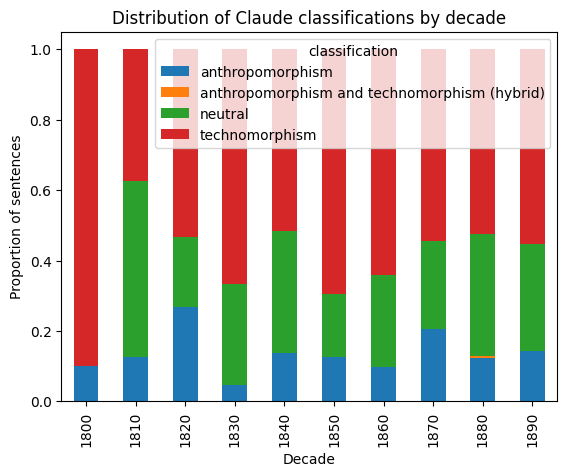

In [40]:
lower_conf_thresh = .1
df_claude_merge[df_claude_merge['human_prediction_max'] > lower_conf_thresh].groupby('decade')['classification'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, title='Distribution of Claude classifications by decade', ylabel='Proportion of sentences', xlabel='Decade')

In [41]:
df_claude_merge.columns

Index(['currentSentence', 'pred_bert_1760_1900', 'genre', 'date', 'decade',
       'id', 'pred_bert_1760_1900_human', 'summary', 'hybrid_binary',
       'explanation', 'classification', 'sentId', 'human_prediction_max'],
      dtype='str')

<Axes: title={'center': 'Distribution of Claude hybrid classifications by decade'}, xlabel='Decade', ylabel='Proportion of sentences'>

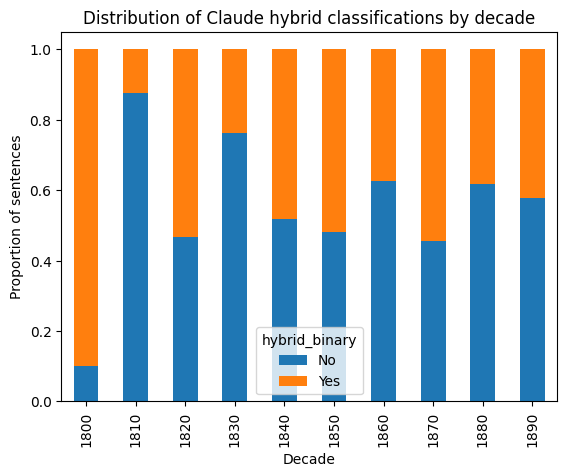

In [42]:


df_claude_merge[df_claude_merge['human_prediction_max'] > lower_conf_thresh].groupby('decade')['hybrid_binary'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, title='Distribution of Claude hybrid classifications by decade', ylabel='Proportion of sentences', xlabel='Decade')

# Analyse Claude with context words

In [43]:
df_ig_perpl.columns

Index(['Token', 'Score', 'Target', 'id', 'Score_normalized',
       'mask_syntax_relation', 'mask_constituent_relation',
       'mask_token_distance', 'Target_position', 'Target_score',
       'Sentence_length', 'Token_id', 'genre', 'token_pseudo_ppl_processed',
       'Token_y', 'perplexity', 'perplexity_threshold', 'diff'],
      dtype='str')

In [44]:
#comparisonTokens = ['child','children', 'boy','boys','girl','girls']
comparisonTokens = chr_categories2word['age_status']
lower_conf_thresh = .1
print(comparisonTokens)
df_comparisonConcept = df_ig_perpl[
    (df_ig_perpl['Target'].isin(comparisonTokens)) & \
    (df_ig_perpl['Target_score'].between(lower_conf_thresh, 1.0)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby('Token').agg(
                        count=('id', 'count'),
                        identifiers=('id', set),
                        avg_diff=('diff', 'mean'), 
                        avg_score=('Score_normalized', 'mean'),
                        avg_perplexity_threshold=('perplexity_threshold', 'mean')
                    ).reset_index()


['child', 'boy', 'girl', 'children', 'boys', 'girls', 'baby', 'lad', 'infant', 'lads', 'youth', 'youths']


In [45]:
def get_proportion_score(ids, target_col):
    proportion_score = df_claude_merge[df_claude_merge.id.isin(ids)][target_col].value_counts(normalize=True)
    return proportion_score

df_comparisonConcept['classification_proportions'] = df_comparisonConcept['identifiers'].apply(lambda x: get_proportion_score(x, 'classification').to_dict())
df_comparisonConcept['hybrid_proportions'] = df_comparisonConcept['identifiers'].apply(lambda x: get_proportion_score(x, 'hybrid_binary').to_dict())
df_comparisonConcept.fillna(0, inplace=True)

,Token,count,identifiers,avg_diff,avg_score,avg_perplexity_threshold,classification_proportions,hybrid_proportions
0,!,35,"{16002, 10376, 4490, 7438, 18327, 1307, 17313,...",-0.002127,0.012855,97.305047,"{'technomorphism': 0.5, 'anthropomorphism': 0....","{'Yes': 0.6153846153846154, 'No': 0.3846153846..."
1,"""",284,"{7180, 7184, 16915, 10268, 18482, 16948, 4149,...",-0.000741,0.004795,26.725307,"{'technomorphism': 0.5210084033613446, 'neutra...","{'Yes': 0.5210084033613446, 'No': 0.4789915966..."
2,%,1,{197},0.000185,0.000861,10000.000000,{'neutral': 1.0},{'No': 1.0}
3,&,1,{14553},-0.041053,-0.032679,10000.000000,{'neutral': 1.0},{'No': 1.0}
4,',222,"{6658, 8708, 12808, 5129, 16905, 10764, 7183, ...",-0.001920,0.002252,9289.761407,"{'technomorphism': 0.5267175572519084, 'neutra...","{'No': 0.5114503816793893, 'Yes': 0.4885496183..."
...,...,...,...,...,...,...,...,...
4337,zest,1,{9015},-0.003573,-0.000771,2.046137,{'anthropomorphism': 1.0},{'Yes': 1.0}
4338,£,1,{12533},-0.001498,0.002235,10000.000000,{'technomorphism': 1.0},{'No': 1.0}
4339,—,123,"{1923, 6, 12039, 13578, 13579, 653, 5006, 7439...",-0.000294,0.001885,10000.000000,"{'technomorphism': 0.618421052631579, 'neutral...","{'No': 0.5394736842105263, 'Yes': 0.4605263157..."
4340,•,2,"{12793, 6514}",0.001932,0.000105,10000.000000,"{'anthropomorphism': 0.5, 'neutral': 0.5}","{'Yes': 0.5, 'No': 0.5}"


In [46]:

expanded = pd.json_normalize(df_comparisonConcept["classification_proportions"])
df_comparisonConcept = pd.concat([df_comparisonConcept.drop(columns=["classification_proportions"]), expanded], axis=1)


In [47]:

expanded = pd.json_normalize(df_comparisonConcept["hybrid_proportions"])
df_comparisonConcept = pd.concat([df_comparisonConcept.drop(columns=["hybrid_proportions"]), expanded], axis=1)


In [48]:
df_comparisonConcept.fillna(0, inplace=True)
df_comparisonConcept['morphism'] = df_comparisonConcept.apply(lambda x: x.anthropomorphism + x.technomorphism, axis=1)


In [49]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 5
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False)

df_result = df_result[df_result['identifiers'].apply(len) >= min_count]
df_result = df_result[df_result['Token'].str.isalpha()]
df_result['count'] = df_result['identifiers'].apply(len)
df_result[['Token','count','avg_score', 'avg_diff']].head(30) # 'anthropomorphism', 'technomorphism', 'Yes'

,Token,count,avg_score,avg_diff
3343,sewing,45,0.034482,-0.018264
420,bathing,14,0.027029,-0.026034
2270,man,55,0.025635,-0.000076
4258,woman,20,0.025396,-0.001359
1646,girls,25,0.024534,0.013886
558,boys,18,0.023996,0.007831
3504,song,5,0.023861,0.016348
2357,mere,122,0.023165,0.000856
730,child,21,0.021038,0.002234
2100,ladies,7,0.018452,0.007233


<Axes: title={'center': 'Distribution of genres for sentences containing "sewing machine" by decade'}, xlabel='Decade', ylabel='Proportion of sentences'>

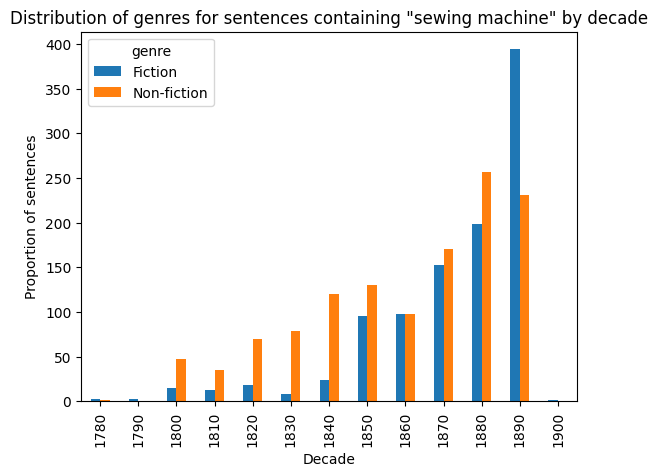

In [50]:
df_sent_all[df_sent_all.currentSentence.str.contains(' man ')].groupby('decade')['genre'].value_counts(normalize=False
                                                                                                                ).unstack().plot(kind='bar', stacked=False, title='Distribution of genres for sentences containing "sewing machine" by decade', ylabel='Proportion of sentences', xlabel='Decade')

In [51]:
dw = df_claude_merge[df_claude_merge['id'].isin(df_result.loc[2270].identifiers)]
dw

,currentSentence,pred_bert_1760_1900,genre,date,decade,id,pred_bert_1760_1900_human,summary,hybrid_binary,explanation,classification,sentId,human_prediction_max
9,"Until his death, my work had been almost that ...","[('child', 0.23), ('slave', 0.11), ('servant',...",Fiction,1857,1850,8214,"{'child': 0.23, 'slave': 0.11, 'servant': 0.08...",The narrator describes his own prior work as m...,No,"'Man' refers to a human generalization, tied t...",technomorphism,8214,0.23
10,"Until his death, my work had been almost that ...","[('child', 0.27), ('boy', 0.08), ('slave', 0.0...",Fiction,1861,1860,8218,"{'child': 0.27, 'boy': 0.08, 'slave': 0.07, 'm...",The sentence describes the narrator's own work...,Yes,'man' refers to human life generally influence...,technomorphism,8218,0.27
20,""" Do you think so; do you really think a man o...","[('woman', 0.26), ('man', 0.25), ('child', 0.1...",Fiction,1885,1880,16451,"{'woman': 0.26, 'man': 0.25, 'child': 0.11, 'b...",The speaker questions whether he is merely a m...,Yes,"'Man' contrasts with 'machine,' highlighting h...",technomorphism,16451,0.26
40,"I was a machine, not a man.","[('woman', 0.32), ('child', 0.27), ('boy', 0.1...",Fiction,1890,1890,16520,"{'woman': 0.32, 'child': 0.27, 'boy': 0.16, 'g...","The sentence explicitly denies humanity, frami...",Yes,"‘I’ and ‘man’ denote human identity, while ‘ma...",technomorphism,16520,0.32
75,"He used to be fiery and impulsive as a boy, he...","[('child', 0.13), ('capacity', 0.12), ('man', ...",Fiction,1891,1890,16620,"{'child': 0.13, 'man': 0.1, 'slave': 0.05, 'bo...",The sentence describes a man fearing he is bec...,Yes,'Man' and 'boy' mark the human subject undergo...,technomorphism,16620,0.13
120,We were talk ing in the room where the cotton ...,"[('weaver', 0.24), ('girl', 0.1), ('man', 0.09...",Non-fiction,1844,1840,16805,"{'weaver': 0.24, 'girl': 0.1, 'man': 0.09, 'wo...",The sentence describes a machine's mechanical ...,No,"{'cotton': ""Refers to the cotton machine, desc...",neutral,16805,0.24
171,"Who speaks of man, then, must not sever Man 's...","[('child', 0.28), ('creature', 0.15), ('mortal...",Fiction,1888,1880,577,"{'child': 0.28, 'creature': 0.15, 'mortal': 0....",The sentence explicitly contrasts man's free w...,No,"'Mere' and 'thing' cast the machine as inert, ...",neutral,577,0.28
206,"Who speaks of man, then, must not sever Man 's...","[('child', 0.27), ('creature', 0.17), ('man', ...",Fiction,1892,1890,692,"{'child': 0.27, 'creature': 0.17, 'man': 0.08,...",The sentence contrasts man with a 'mere machin...,No,"'Mere' signals diminishment, marking the machi...",neutral,692,0.27
220,"It gets completely over a man, and makes him f...","[('child', 0.23), ('brute', 0.13), ('animal', ...",Fiction,1850,1850,8935,"{'child': 0.23, 'brute': 0.13, 'man': 0.03, 'c...",The sentence explicitly contrasts human vitali...,No,man: refers to human subject experiencing feel...,neutral,8935,0.23
244,"Who speaks of man, then, must not sever Man 's...","[('child', 0.28), ('creature', 0.13), ('mortal...",Fiction,1898,1890,812,"{'child': 0.28, 'creature': 0.13, 'mortal': 0....",The sentence contrasts man with a 'mere machin...,No,"'Mere' signals dismissiveness toward machines,...",neutral,812,0.28


In [52]:
import re
tqdm.pandas()
df_result['Token_count'] = df_result.progress_apply(lambda row: df_sent_all['currentSentence'].apply(lambda x: bool(re.findall(rf'\b{row["Token"]}\b', x.lower()))).sum(), axis=1)

100%|██████████| 494/494 [02:28<00:00,  3.32it/s]


In [53]:
#df_result['Token_count'] = df_result.progress_apply(lambda row: df_sent_all[row['identifiers']].apply(lambda x: bool(re.findall(rf'\b{row["Token"]}\b', x.lower()))).sum(), axis=1)

In [54]:
df_result['avg_perpl_all'] = df_result.progress_apply(lambda x: df_sent_all['token_pseudo_ppl_processed'].apply(lambda y: dict(y).get(x['Token'], 0)).mean(), axis=1)
#df_result['avg_perplexity_threshold'] = df_result['avg_perplexity_threshold'].fillna(0)
df_result['perplexity_diff'] = df_result['avg_perplexity_threshold'] - df_result['avg_perpl_all'] 

100%|██████████| 494/494 [01:58<00:00,  4.18it/s]


In [55]:
df_result['perc_fiction'] = df_result.progress_apply(lambda x: df_sent[df_sent.index.isin(x['identifiers'])]['genre'].value_counts(normalize=True).get('Fiction', 0), axis=1)

100%|██████████| 494/494 [00:00<00:00, 1076.30it/s]


In [56]:
df_result['Token_percentage'] = df_result.apply(lambda row:  (row['count'] / row['Token_count']) * 100, axis=1)

In [57]:
print(df_result[
    ['Token','count','avg_score','avg_diff','avg_perplexity_threshold','perplexity_diff','Token_percentage','perc_fiction','anthropomorphism', 'technomorphism']
    ].head(20).to_latex(float_format="%.3f",index=False, caption=f"Tokens predictive of the age_status concept in the {collection} collection for the target token '{TargetMaskedToken}' with at least {min_count} sentences. The table shows the average score, average difference from the target token, average perplexity threshold, difference in perplexity threshold compared to all sentences, percentage of sentences containing the token, percentage of sentences in the Fiction genre, and proportions of anthropomorphism and technomorphism classifications."))

\begin{table}
\caption{Tokens predictive of the age_status concept in the blb collection for the target token 'machine' with at least 5 sentences. The table shows the average score, average difference from the target token, average perplexity threshold, difference in perplexity threshold compared to all sentences, percentage of sentences containing the token, percentage of sentences in the Fiction genre, and proportions of anthropomorphism and technomorphism classifications.}
\begin{tabular}{lrrrrrrrrr}
\toprule
Token & count & avg_score & avg_diff & avg_perplexity_threshold & perplexity_diff & Token_percentage & perc_fiction & anthropomorphism & technomorphism \\
\midrule
sewing & 45 & 0.034 & -0.018 & 137.754 & 36.466 & 1.931 & 0.711 & 0.267 & 0.178 \\
bathing & 14 & 0.027 & -0.026 & 277.726 & -45.730 & 0.889 & 0.643 & 0.429 & 0.000 \\
man & 55 & 0.026 & -0.000 & 85.324 & 35.844 & 1.799 & 0.709 & 0.127 & 0.600 \\
woman & 20 & 0.025 & -0.001 & 455.665 & 447.619 & 4.926 & 0.950 & 0.250

In [58]:
df_claude_merge[df_claude_merge['id'].isin(df_result.loc[2270].identifiers)]

,currentSentence,pred_bert_1760_1900,genre,date,decade,id,pred_bert_1760_1900_human,summary,hybrid_binary,explanation,classification,sentId,human_prediction_max
9,"Until his death, my work had been almost that ...","[('child', 0.23), ('slave', 0.11), ('servant',...",Fiction,1857,1850,8214,"{'child': 0.23, 'slave': 0.11, 'servant': 0.08...",The narrator describes his own prior work as m...,No,"'Man' refers to a human generalization, tied t...",technomorphism,8214,0.23
10,"Until his death, my work had been almost that ...","[('child', 0.27), ('boy', 0.08), ('slave', 0.0...",Fiction,1861,1860,8218,"{'child': 0.27, 'boy': 0.08, 'slave': 0.07, 'm...",The sentence describes the narrator's own work...,Yes,'man' refers to human life generally influence...,technomorphism,8218,0.27
20,""" Do you think so; do you really think a man o...","[('woman', 0.26), ('man', 0.25), ('child', 0.1...",Fiction,1885,1880,16451,"{'woman': 0.26, 'man': 0.25, 'child': 0.11, 'b...",The speaker questions whether he is merely a m...,Yes,"'Man' contrasts with 'machine,' highlighting h...",technomorphism,16451,0.26
40,"I was a machine, not a man.","[('woman', 0.32), ('child', 0.27), ('boy', 0.1...",Fiction,1890,1890,16520,"{'woman': 0.32, 'child': 0.27, 'boy': 0.16, 'g...","The sentence explicitly denies humanity, frami...",Yes,"‘I’ and ‘man’ denote human identity, while ‘ma...",technomorphism,16520,0.32
75,"He used to be fiery and impulsive as a boy, he...","[('child', 0.13), ('capacity', 0.12), ('man', ...",Fiction,1891,1890,16620,"{'child': 0.13, 'man': 0.1, 'slave': 0.05, 'bo...",The sentence describes a man fearing he is bec...,Yes,'Man' and 'boy' mark the human subject undergo...,technomorphism,16620,0.13
120,We were talk ing in the room where the cotton ...,"[('weaver', 0.24), ('girl', 0.1), ('man', 0.09...",Non-fiction,1844,1840,16805,"{'weaver': 0.24, 'girl': 0.1, 'man': 0.09, 'wo...",The sentence describes a machine's mechanical ...,No,"{'cotton': ""Refers to the cotton machine, desc...",neutral,16805,0.24
171,"Who speaks of man, then, must not sever Man 's...","[('child', 0.28), ('creature', 0.15), ('mortal...",Fiction,1888,1880,577,"{'child': 0.28, 'creature': 0.15, 'mortal': 0....",The sentence explicitly contrasts man's free w...,No,"'Mere' and 'thing' cast the machine as inert, ...",neutral,577,0.28
206,"Who speaks of man, then, must not sever Man 's...","[('child', 0.27), ('creature', 0.17), ('man', ...",Fiction,1892,1890,692,"{'child': 0.27, 'creature': 0.17, 'man': 0.08,...",The sentence contrasts man with a 'mere machin...,No,"'Mere' signals diminishment, marking the machi...",neutral,692,0.27
220,"It gets completely over a man, and makes him f...","[('child', 0.23), ('brute', 0.13), ('animal', ...",Fiction,1850,1850,8935,"{'child': 0.23, 'brute': 0.13, 'man': 0.03, 'c...",The sentence explicitly contrasts human vitali...,No,man: refers to human subject experiencing feel...,neutral,8935,0.23
244,"Who speaks of man, then, must not sever Man 's...","[('child', 0.28), ('creature', 0.13), ('mortal...",Fiction,1898,1890,812,"{'child': 0.28, 'creature': 0.13, 'mortal': 0....",The sentence contrasts man with a 'mere machin...,No,"'Mere' signals dismissiveness toward machines,...",neutral,812,0.28


## Claude Summary

In [299]:
text = '\n\n'.join(df_claude_merge[df_claude_merge['id'].isin(df_result.loc[4258].identifiers)][['currentSentence','summary']].apply(lambda x: f"Sentence: {x['currentSentence']}\nSummary: {x['summary']}", axis=1))
prompt = f"""
Below are sentence paired with a summary. These sentences are taken from nineteen century fiction and non-fiction and reflect on the relation between 'machine' and '{df_result.loc[4258].Token}'.
Read through these sentence and carefully reflect whether these sentences reflect a hybrid understanding of machines, or contains anthropomorphist or technomorphist elements? 
After this, write a short essay on the main themes present in these data. Use heading to make the structure of your essay clear. Use the sentences as evidence to support your argument. Don't make stuff up, only use the sentences and summaries provided as evidence.

{text}"""
prompt

'\nBelow are sentence paired with a summary. These sentences are taken from nineteen century fiction and non-fiction and reflect on the relation between \'machine\' and \'woman\'.\nRead through these sentence and carefully reflect whether these sentences reflect a hybrid understanding of machines, or contains anthropomorphist or technomorphist elements? \nAfter this, write a short essay on the main themes present in these data. Use heading to make the structure of your essay clear. Use the sentences as evidence to support your argument. Don\'t make stuff up, only use the sentences and summaries provided as evidence.\n\nSentence: She is a thing to be loved, Ludlow; trust me, I never yet set affections on woman with the warmth I feel for the faithful and beautiful machine. "\nSummary: The machine is called \'she,\' described as \'faithful and beautiful,\' and loved with human warmth, blending mechanical and emotional registers—clear anthropomorphism showing a hybrid understanding of mach

In [300]:
result = prompt_claude_with_retry(client=anthropic_client, messages=[{"role": "user", "content": prompt}], model="claude-opus-5", max_tokens=2048)

In [298]:
print(result.content[-1].text)

## 1. What the sample actually contains

Read as a set, these twenty passages are not primarily *about* machines. They are about a boundary — the boundary between the woman and the mechanism — and almost every sentence is engaged in either crossing it, policing it, or worrying at it. Only three or four are genuinely inert.

It is useful to sort them by the **direction of transfer**:

**(a) Machine → human (anthropomorphism proper): 5 instances**
- The engineer's declaration to Ludlow: the machine is "she," "faithful and beautiful," and the object of affections warmer than any he has felt "on woman."
- "A small machine that can sew like a woman."
- The sewing machine talked of in the village as "something uncanny."
- "The 'old one' be come to us… him be there!" — the machine as the Devil, pronominally personified ("him") and spatially inhabiting the house.
- "These machines will ruin women as needleworkers" — the machine as a social agent with destructive power, set against the claim th

# Perplexity and themes

In [59]:
df_sent_all['pred_bert_1760_1900_age_status_max'] = df_sent_all['pred_bert_1760_1900_age_status'].apply(lambda x: max([s for w, s in dict(x).items()]+[0] ))
df_sent_all['pred_bert_1760_1900_age_status_bool'] = df_sent_all.apply(lambda x: x['pred_bert_1760_1900_age_status_max'] > 0.4, axis=1)

<Axes: xlabel='perplexity_threshold', ylabel='genre'>

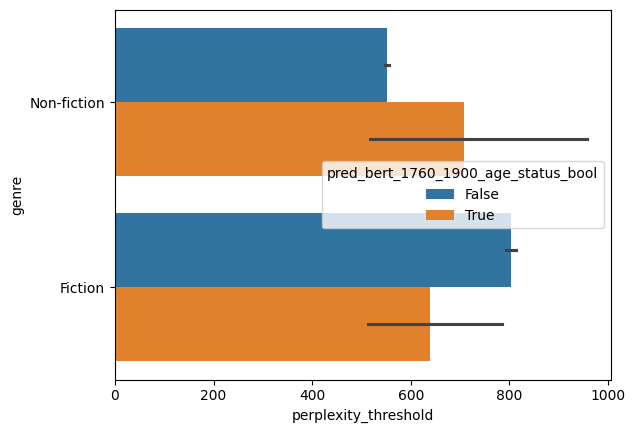

In [60]:
sns.barplot(x='perplexity_threshold', y='genre', hue='pred_bert_1760_1900_age_status_bool', data=df_sent_all[df_sent_all['decade'].between(1800,1899)])

#.plot(kind='bar', title='Average Perplexity by Genre and Human Prediction', ylabel='Average Perplexity', xlabel='Genre')

# Analysis: Zooming in on sentences based on context words

You can zoom in a sentences with using the predictive context words. Change the `id` variable below with one of the index numbers of the`df_result` dataframe.

The sentence are ranked, with examples where the context word obtains the highest scores, first.

You can change the following variable:

- `id` selected from the `df_result` dataframe
- `sort_value` how do sort the sentences, i.e. where the impact of the target word is thelargest ('Score_normalized') or makes the biggest difference ('diff')

In [61]:
pd.set_option('display.max_colwidth', 200)

In [62]:
id =  4258#1637
sort_value = 'diff' #'Score_normalized' | 'diff'


identifiers_ranked = df_ig_perpl.loc[df_ig_perpl['id'].isin(list(df_result.loc[id].identifiers)) \
                             & (df_ig_perpl['Token']==df_result.loc[id].Token) \
                             & df_ig_perpl['Target'].isin(comparisonTokens)
                             
                             ].sort_values(by=sort_value, ascending=False)['id'].unique()
sentences_ranked = df_sent.iloc[list(identifiers_ranked)].head(20)
sentences_ranked.currentSentence

2610                                                                                                                                          She 's kind, and talks to me as if I were a woman — not a machine.
15657    And now, though she had discovered the old woman 's strange antipathy to the machine, she thought it would be wiser to try to conquer her prejudice by a daily use of it, than, by giving way, rende...
15660                                                                  — tell I what be your trouble ?" " The ' old one ' be come to us, " said the old woman; " him be there !" and she pointed to the machine.
4508                                                                 " I ai not no patience with ' notions, ' ' said the woman angrily, for the thread in the needle of the machine broke just then with a jerk.
10438                                                                                                                                                    I had a wom

In [63]:
# Optional: save and expeort sentences
name = 'child'
outPath = Path('sentences')
outPath.mkdir(exist_ok=True)
sentences_ranked.to_csv(outPath / f'{name}_sentences.csv', index=False)

In [64]:
modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Analysis: Inspect IG for one sentence

In [65]:
%load_ext autoreload
%autoreload 2

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Saved figure to highlights_a4.pdf


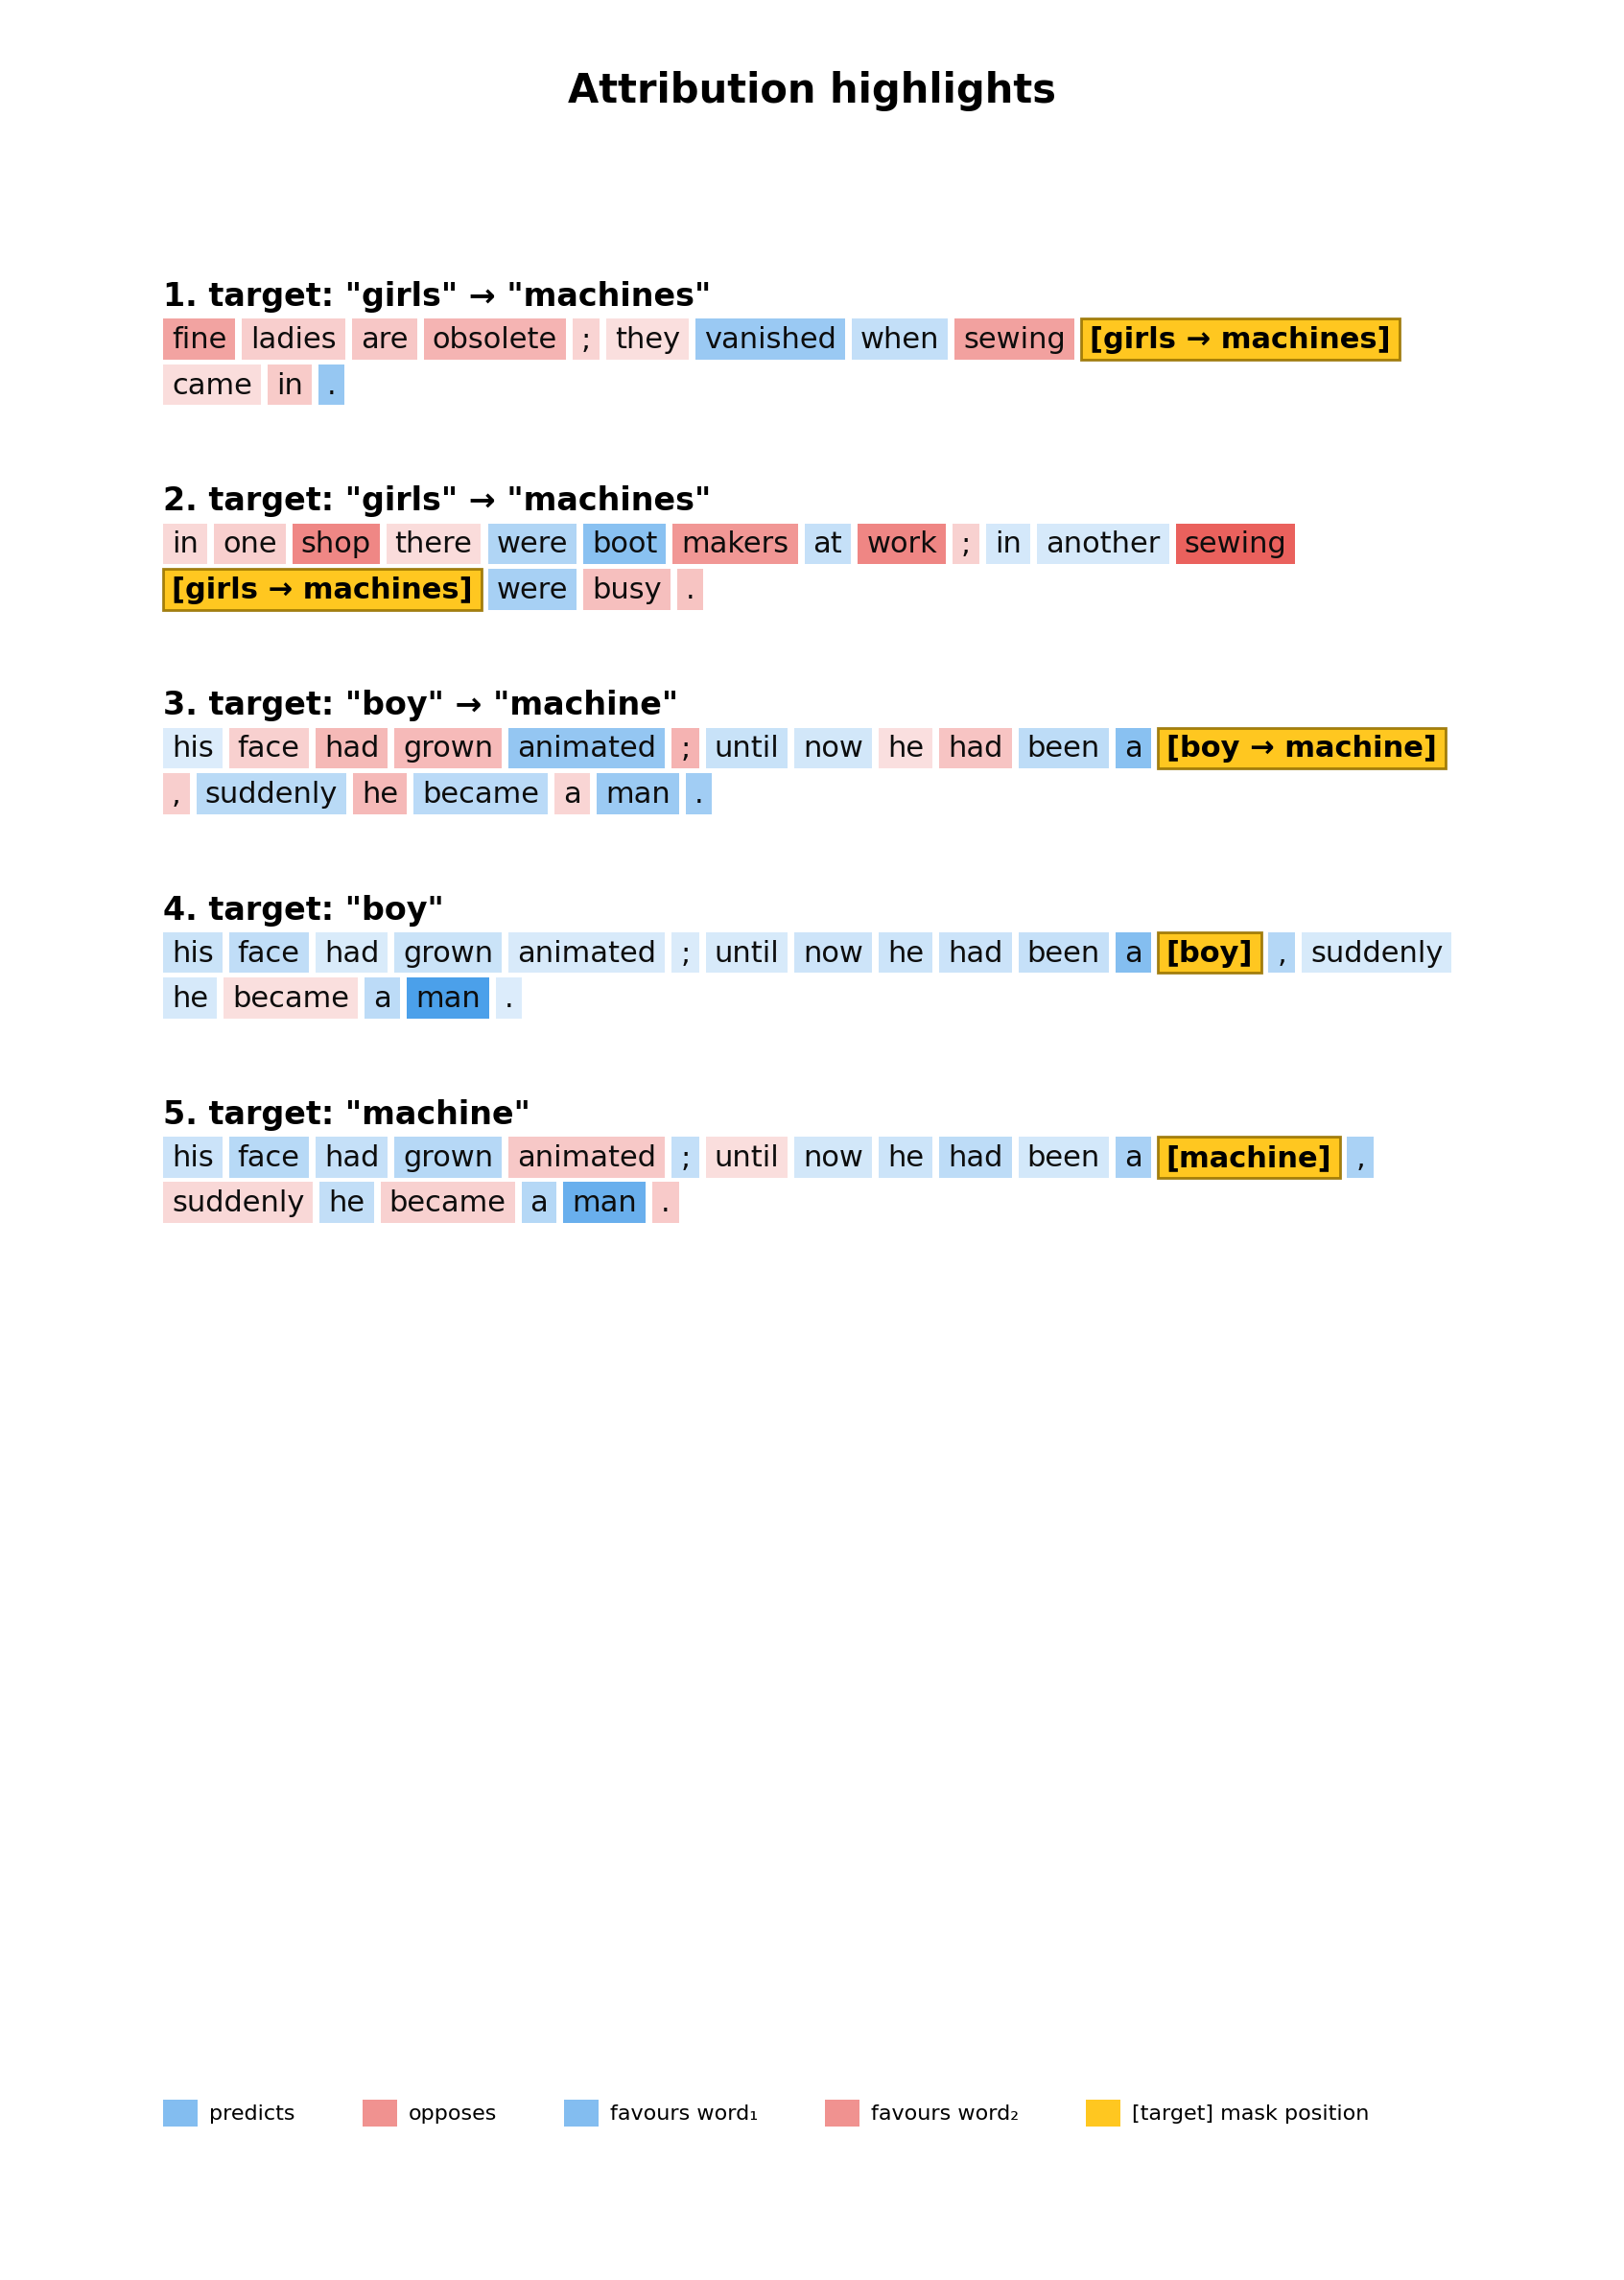

In [69]:
from explain.visualise import plot_highlighted_sentences
fig, ax = plot_highlighted_sentences(
    explainer,
    items=[
        ("Fine ladies are obsolete; they vanished when sewing [MASK] came in.", ["girls","machines"]),
        ("In one shop there were boot makers at work; in another sewing [MASK] were busy.", ["girls","machines"]),
        ('His face had grown animated; until now he had been a [MASK], suddenly he became a man.', ["boy","machine"]),
        ('His face had grown animated; until now he had been a [MASK], suddenly he became a man.', "boy"),
        ('His face had grown animated; until now he had been a [MASK], suddenly he became a man.', "machine")
        ],
    title="Attribution highlights",
    save_path="highlights_a4.pdf",
)


In [70]:
idx = 4384
target_token = 'predicted' # 'actual' | 'predicted'

sentence = df_sent.iloc[idx].maskedSentence

if target_token == 'actual':
    target_token = df_sent.iloc[idx].targetExpression
elif target_token == 'predicted':
    target_token =  [w for w, v in sorted(
       df_sent.iloc[idx].pred_bert_contemporary_human.items(), key=lambda x: x[1], reverse=True)
                     if w in wordList][0]
print(target_token)

NameError: name 'wordList' is not defined

In [ ]:

highlight_context_tokens(explainer, sentence, target=target_token, word_agg="mean")

In [ ]:

highlight_context_tokens(explainer, sentence, target=target_token, word_agg="mean")

## Inspect sentences based on Context and Predicted token

In [ ]:
predictedToken = 'men'
contextToken = 'animal'
sort_value = 'diff' #'Score_normalized' | 'diff'

ids = df_ig[(df_ig['Token'].str.lower() == contextToken) & (df_ig['Target'].str.lower() == predictedToken)
                    ].sort_values(sort_value,ascending=False).id.values

In [ ]:
idx = 4495
wordList = human_words
sentence = df_sent.iloc[idx].maskedSentence
targets = list(set(df_ig[df_ig['id'] == idx].Target.unique()).intersection(set(wordList)))
target_expression = df_sent.iloc[idx].targetExpression

In [ ]:
print(f"Sentence: {sentence}")
print(f"Targets: {targets}")
print(f"Targets: {target_expression}")

In [ ]:
#target =targets[0]

In [ ]:

highlight_context_tokens(explainer, sentence, target=predictedToken, word_agg="mean")

# Notebook still under construction here, please ignore or run at your own risk! :-)

## Genre and Patterns

In [ ]:
df_ig_merged = df_ig.merge(df_sent[['decade','date','genre']], left_on='id',right_index=True, how='left')
df_ig.shape, df_ig_merged.shape

In [ ]:
df_ig_merged.columns

In [ ]:
cutoff = df_ig_merged[df_ig_merged.Score_normalized > 0].Score_normalized.mean()
df_ig_merged_cut = df_ig_merged[df_ig_merged.Score_normalized > cutoff].reset_index(drop=True)
df_ig_merged_cut = df_ig_merged_cut[~df_ig_merged_cut['Token'].isin(['[MASK]','.',',', '!', '?'])]

In [ ]:
grouped = df_ig_merged_cut.groupby('id')


for n in range(2,6):

    df_ig_merged_cut[f'ngram_{n}'] = df_ig_merged_cut['Token']
    for i in range(1, n):
        df_ig_merged_cut[f'ngram_{n}'] = df_ig_merged_cut[f'ngram_{n}'] + ' ' + grouped['Token'].shift(-i)


    df_ig_merged_cut[f'ngram_mean_{n}'] = (
        df_ig_merged_cut.groupby('id')['Score_normalized']
        .rolling(window=n)
        .mean()
        .reset_index(level=0, drop=True)
    )
    df_ig_merged_cut[f'ngram_mean_{n}'] = df_ig_merged_cut.groupby('id')[f'ngram_mean_{n}'].shift(-(n-1))

In [ ]:
#comparisonTokens = ['child','children', 'boy','boys','girl','girls']
n = 4
comparisonTokens = chr_categories2word['age_status']
target_tokens = ['machine','machines'] # we look at the predictions for all the non machine words
df_comparisonConcept = df_ig_merged_cut[
    #(df_ig_merged_cut['Target'].isin(comparisonTokens)) & \
    (~df_ig_merged_cut['Target'].isin(target_tokens)) & \
    (df_ig_merged_cut['Target_score'].between(0.4, 1.0)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby(f'ngram_{n}').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


In [ ]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 2
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False)
df_result.head(20)

# Genre

In [ ]:
#comparisonTokens = ['child','children', 'boy','boys','girl','girls']
comparisonTokens = chr_categories2word['age_status']
df_comparisonConcept = df_ig_merged[
    (df_ig_merged['Target'].isin(comparisonTokens)) & \
    
    (df_ig_merged['Target_score'].between(0.4, 1.0)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby(['genre','Token']).agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


In [ ]:

genre_scores = (
    df_comparisonConcept
    .pivot(index='Token', columns='genre', values=['avg_score', 'avg_diff', 'count'])
)

df_genre_diff = (
    genre_scores[('avg_score', 'Fiction')] - genre_scores[('avg_score', 'Non-fiction')]
).fillna(0).sort_values(ascending=False)

df_genre_diff.tail(20)

In [ ]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 5
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False)
df_result.head(20)

## Historical Experiments

In [ ]:
min_sentence_length = 20
max_sentence_length = 200   
min_confidence = .1
column_name = 'Score_normalized' # Score_normalized | diff

df_ig_merged[(df_ig_merged['Target'].isin(['machine','machines'])) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot(title=f'Average {column_name} in scores for tokens predictive of the contrastive concept over time.', xlabel='Decade', ylabel='Average difference in scores', figsize=(15, 4))

df_ig_merged[(~df_ig_merged['Target'].isin(['machine','machines'])) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot()

df_ig_merged[(df_ig_merged['Target'].isin(comparisonTokens)) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot()

In [ ]:
df_ig['sent_diff'] = df_ig.groupby('id')['diff'].transform(lambda x: x.mean())
df_ig['sent_diff'] = df_ig.groupby('id')['diff'].transform(lambda x: x.mean())
sent_diff_scores = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                          (df_ig['Target_score'].between(.1,1.0)) & \
                          (df_ig['Sentence_length'] > 20)
                          ].drop_duplicates(subset=['id'])['sent_diff']
#sent_diff_scores.plot(kind='hist', bins=100, title=f'Histogram of average difference in scores for tokens predictive of the contrastive concept.', xlabel='Average difference in scores', ylabel='Count')

In [ ]:
sent_diff_scores = df_ig[~df_ig['Target'].isin(['machine','machines'])].drop_duplicates(subset=['id'])['sent_diff']
sent_diff_scores.plot(kind='hist', bins=100, title=f'Histogram of average difference in scores for tokens predictive of the contrastive concept.', xlabel='Average difference in scores', ylabel='Count')

## Analysis: Sentences where we observe largest changes 

In [ ]:
min_confidence = .1
max_confidence = 1.0
min_sentence_length = 50
max_sentence_length = 200
n_examples = 10000

most_changes = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                      (df_ig['Target_score'].between(min_confidence, max_confidence)) & \
                      (df_ig['Sentence_length'].between(min_sentence_length, max_sentence_length))
                      ].sort_values(by='sent_diff', ascending=False)[['id','sent_diff','Target','Token']]['id'].unique()[:n_examples]

In [ ]:
pd.set_option('display.max_colwidth', 200)
df_sel_sent = df_sent.iloc[most_changes]
df_sel_sent.currentSentence

In [ ]:
min_confidence = .1
max_confidence = 1.0
min_sentence_length = 50
max_sentence_length = 200
n_examples = 100

minimal_changes = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                      (df_ig['Target_score'].between(min_confidence, max_confidence)) & \
                      (df_ig['Sentence_length'].between(min_sentence_length, max_sentence_length)) & \
                      (df_ig['sent_diff'].between(-0.005,0.005))
                      ].sort_values(by='sent_diff', ascending=True)[['id','sent_diff','Target','Token']]['id'].unique()[:n_examples]

In [ ]:
pd.set_option('display.max_colwidth', 200)
df_sel_sent = df_sent.iloc[minimal_changes]
df_sel_sent.currentSentence

In [ ]:
idx = 17071 #15972
target_token = 'predicted' # 'actual' | 'predicted'

sentence = df_sent.iloc[idx].maskedSentence

if target_token == 'actual':
    target_token = df_sent.iloc[idx].targetExpression
elif target_token == 'predicted':
    target_token =  [w for w, v in sorted(
       df_sent.iloc[idx].pred_bert_contemporary_human.items(), key=lambda x: x[1], reverse=True)
                     if w in wordList][0]
print(target_token)

In [ ]:

highlight_context_tokens(explainer, sentence, target=target_token, word_agg="mean")

## qa: which predicted words change the context dependencies the least?

## Linear trends

In [ ]:
df_ig_by_token = df_ig_merged.groupby(['Token','decade'])['Score_normalized'].mean().reset_index()

In [ ]:
words = [w for w,v in Counter(df_ig['Token']).items() if v > 100]

In [ ]:
from sklearn.linear_model import LinearRegression
def get_linear_regression_slope(df, x_col='decade', y_col='Score_normalized'):
    X = df[[x_col]].values
    y = df[y_col].values
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0] # Return the slope

In [ ]:
slopes = df_ig_by_token.groupby('Token').apply(lambda x: get_linear_regression_slope(x))
slopes.loc[words].sort_values(ascending=False)

In [ ]:
token = 'sewing'
df_ig_merged[df_ig_merged.Token==token].groupby('decade')['Score_normalized'].mean().plot(title=f'Average score for the token "{token}" over time.', xlabel='Decade', ylabel='Average score', figsize=(15, 4))

# Topic Modelling

In [ ]:
from explain.topicbert_viz import embed_sentences

In [ ]:
df_topic_model = df_sent.copy()

In [ ]:
sentences = df_sent.currentSentence.tolist()

embeddings = embed_sentences(
    sentences,
    checkpoint=modelName,
    batch_size=32,
    normalize=True,
    device=pick_device()
)

print(embeddings.shape)
# torch.Size([3, 768])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import plotly.express as px

In [ ]:
embeddings = np.asarray(embeddings)
df_topic_model["embeddings"] = list(embeddings)

In [ ]:
 tsne = TSNE(
        n_components=2,
        perplexity=min(30, len(df_topic_model) - 1),
        random_state=42,
        init="pca",
    )

In [ ]:
coords = tsne.fit_transform(embeddings)

df_topic_model["tsne_x"] = coords[:, 0]
df_topic_model["tsne_y"] = coords[:, 1]


In [ ]:
df_topic_model = df_topic_model.merge(
    df_ig[['id', 'sent_diff']].drop_duplicates(),
    left_index=True, right_on='id', how='left'
    )
df_topic_model.shape

In [ ]:
df_topic_model['sent_diff_abs'] = df_topic_model['sent_diff'].abs().fillna(0)

In [ ]:
df_topic_model['sent_diff_abs']

In [ ]:
fig = px.scatter(
        df_topic_model,
        x="tsne_x",
        y="tsne_y",
        color='decade',
        size='sent_diff_abs',
        hover_data=["currentSentence", "decade"],
        title="t-SNE of Sentence Embeddings",
        

    )

fig.update_traces(marker=dict( opacity=0.7), selector=dict(mode='markers'))
fig.update_layout(
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
        template="plotly_white",
    )

fig.show()

In [ ]:
# from explain.topicbert_viz import draw_scatterplot_regions

# fig_with_regions = draw_scatterplot_regions(
#     fig,
#     df,
#     region_col="decade",
#     label_col="decade",
# )

# fig_with_regions.show()


In [ ]:
# import plotly.express as px
# from explain.topicbert_viz import draw_clustered_scatterplot_regions

# fig_clustered_regions = px.scatter(
#     df,
#     x="tsne_x",
#     y="tsne_y",
#     color="decade",
#     hover_data=["currentSentence", "decade"],
#     title="Scatterplot regions from automatic clustering",
# )

# fig_clustered_regions, clustered_regions_df, clustered_regions_summary = draw_clustered_scatterplot_regions(
#     fig_clustered_regions,
#     df,
#     x_col="tsne_x",
#     y_col="tsne_y",
#     method="kmeans",
#     n_clusters=6,
#     min_points=4,
# )

# fig_clustered_regions.show()


In [ ]:
from explain.topicbert_viz import plot_topicbert_topics

In [ ]:
df_topic_model['currentSentence_clean'] = df_topic_model['currentSentence'].str.lower().replace(r'machine|machines', '', regex=True).str.lower().str.strip()

In [ ]:
topicbert_frame, topicbert_summary, topicbert_doc_topic_distributions, topicbert_fig = plot_topicbert_topics(
    model=explainer.model,
    dataframe=df_topic_model,
    text_column="currentSentence_clean",
    tokenizer=explainer.tokenizer,
    max_rows=-1,
    batch_size=8,
    max_length=96,
    embed_device="cpu",
    cluster_method="kmeans",
    n_clusters=20,
)

topicbert_summary

topicbert_doc_topic_distributions.head()

#topicbert_fig.show()

In [ ]:
display(topicbert_frame.currentSentence_clean[:3])
display(df_topic_model.currentSentence_clean[:3])

In [ ]:
df_topic_concat = pd.concat([topicbert_frame, df_topic_model.reset_index()], ignore_index=True, axis=1)

In [ ]:
df_topic_concat.columns = list(topicbert_frame.columns) + list(df_topic_model.reset_index().columns)
df_topic_concat = df_topic_concat.loc[:,~df_topic_concat.columns.duplicated()].copy()

In [ ]:
df_topic_concat.columns

In [ ]:
df_topic_dist_concat = pd.concat([topicbert_doc_topic_distributions, df_topic_model.reset_index()], ignore_index=True, axis=1)
df_topic_dist_concat.columns = list(topicbert_doc_topic_distributions.columns) + list(df_topic_model.reset_index().columns)
df_topic_dist_concat = df_topic_dist_concat.loc[:,~df_topic_dist_concat.columns.duplicated()].copy()
df_topic_dist_concat

In [ ]:
#topicbert_frame_merged = topicbert_frame.merge(df[['currentSentence_clean','currentSentence','decade']], left_on='currentSentence_clean', right_on='currentSentence_clean', how='left')

In [ ]:
fig = px.scatter(
        df_topic_concat,
        x="tsne_x",
        y="tsne_y",
        color='topic_label',
        size='sent_diff_abs',
        hover_data=["currentSentence", "topic_name"],
        title="t-SNE of Sentence Embeddings",
        

    )

fig.update_traces(marker=dict(opacity=0.6), selector=dict(mode='markers'))
fig.update_layout(
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
        template="plotly_white",
    )

fig.show()

In [ ]:
path = Path("visualisation")
path.mkdir(exist_ok=True)

fig.write_html(f"{path}/topicbert_visualisation_low_diff.html")

In [ ]:
df_topic_dist_concat['sent_diff_z'] = (df_topic_dist_concat['sent_diff'] - df_topic_dist_concat['sent_diff'].mean()) / df_topic_dist_concat['sent_diff'].std()
df_topic_dist_concat['sent_diff_bool'] = df_topic_dist_concat['sent_diff_z'] >= 1

In [ ]:
topic_label = 15
topiclab =df_topic_dist_concat.groupby(['sent_diff_bool'])[[topic_label for topic_label in df_topic_dist_concat.columns if topic_label.startswith('topic_prob_')]
                                                 ].mean()#.plot(kind='bar', title=f'Average topic probability for sentences with high vs low difference in scores for tokens predictive of the contrastive concept.', xlabel='Sentences with high vs low difference in scores', ylabel='Average topic probability', figsize=(15,5))

In [ ]:
topiclab.T.plot(kind='bar', title=f'Average topic probability for sentences with high vs low difference in scores for tokens predictive of the contrastive concept.', xlabel='Sentences with high vs low difference in scores', ylabel='Average topic probability', figsize=(15,5))

In [ ]:
df_topic_dist_concat['sent_length'] = df_topic_dist_concat['currentSentence'].str.split().apply(len)
df_topic_dist_concat.columns

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from explain import regression_analysis as ra

analysis = ra.RegressionAnalysis(df_topic_dist_concat, y="sent_diff",
                            x=["sent_length"] + [f"topic_prob_{i}" for i in range(20)],
                            y_range="-1_1")
analysis.fit(model="fractional_logit")
print(analysis.summary())


In [ ]:

analysis.plot_actual_vs_predicted()
analysis.plot_residuals()
analysis.plot_coefficients()
analysis.plot_correlation_heatmap()

print(analysis.vif())
print(analysis.performance_metrics())